In [1]:
%pip install ucimlrepo


Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo

In [2]:
energy = fetch_ucirepo(id=374)
X_raw = energy.data.features.copy()
y_raw = energy.data.targets.squeeze().astype(float)

In [4]:
df = X_raw.copy()
df["Appliances"] = y_raw.to_numpy()
df["date"] = pd.to_datetime(
    df["date"].astype(str).str.replace(" ", "").str.strip(),
    format="%Y-%m-%d%H:%M:%S"
)
df = df.sort_values("date").reset_index(drop=True)

In [5]:
df["hour_sin"] = np.sin(2 * np.pi * df["date"].dt.hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["date"].dt.hour / 24)
df["day_of_week"] = df["date"].dt.dayofweek

In [6]:
y = df.pop("Appliances")
X = df.drop(columns="date")
print(X.shape)
display(X.head())

(19735, 30)


,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,hour_sin,hour_cos,day_of_week
0,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,...,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433,-0.965926,-0.258819,0
1,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,...,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195,-0.965926,-0.258819,0
2,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,...,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668,-0.965926,-0.258819,0
3,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,...,733.8,92.0,6.000000,51.500000,5.0,45.410390,45.410390,-0.965926,-0.258819,0
4,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,...,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097,-0.965926,-0.258819,0


In [7]:
display(X.describe().T)
print("Nulos:", int(X.isna().sum().sum()))
print(y.describe())

,count,mean,std,min,25%,50%,75%,max
lights,19735.0,3.801875,7.935988,0.000000,0.000000,0.000000e+00,0.000000,70.000000
T1,19735.0,21.686571,1.606066,16.790000,20.760000,2.160000e+01,22.600000,26.260000
RH_1,19735.0,40.259739,3.979299,27.023333,37.333333,3.965667e+01,43.066667,63.360000
T2,19735.0,20.341219,2.192974,16.100000,18.790000,2.000000e+01,21.500000,29.856667
RH_2,19735.0,40.420420,4.069813,20.463333,37.900000,4.050000e+01,43.260000,56.026667
T3,19735.0,22.267611,2.006111,17.200000,20.790000,2.210000e+01,23.290000,29.236000
RH_3,19735.0,39.242500,3.254576,28.766667,36.900000,3.853000e+01,41.760000,50.163333
T4,19735.0,20.855335,2.042884,15.100000,19.530000,2.066667e+01,22.100000,26.200000
RH_4,19735.0,39.026904,4.341321,27.660000,35.530000,3.840000e+01,42.156667,51.090000
T5,19735.0,19.592106,1.844623,15.330000,18.277500,1.939000e+01,20.619643,25.795000


Nulos: 0
count    19735.000000
mean        97.694958
std        102.524891
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1080.000000
Name: Appliances, dtype: float64


In [8]:
print((X["rv1"] == X["rv2"]).all())
print(X["rv1"].corr(X["rv2"]))

True
1.0


Parte 4

In [9]:
n = len(X)
fin_train = int(0.70 * n)
fin_val = int(0.85 * n)

In [10]:
X_train, y_train = X.iloc[:fin_train], y.iloc[:fin_train]
X_val, y_val = X.iloc[fin_train:fin_val], y.iloc[fin_train:fin_val]
X_test, y_test = X.iloc[fin_val:], y.iloc[fin_val:]

In [11]:
print("train:", X_train.shape, "| val:", X_val.shape, "| test:", X_test.shape)
print("Media del objetivo -> train: %.1f | val: %.1f | test: %.1f" % (y_train.mean(), y_val.mean(), y_test.mean()))

train: (13814, 30) | val: (2960, 30) | test: (2961, 30)
Media del objetivo -> train: 98.8 | val: 93.4 | test: 96.9


Parte 5

,corr_pearson
hour_sin,-0.250193
hour_cos,-0.226071
lights,0.225525
T2,0.149626
RH_out,-0.147125
T3,0.121399
RH_8,-0.115910
T6,0.108138
T_out,0.092864
RH_1,0.089316


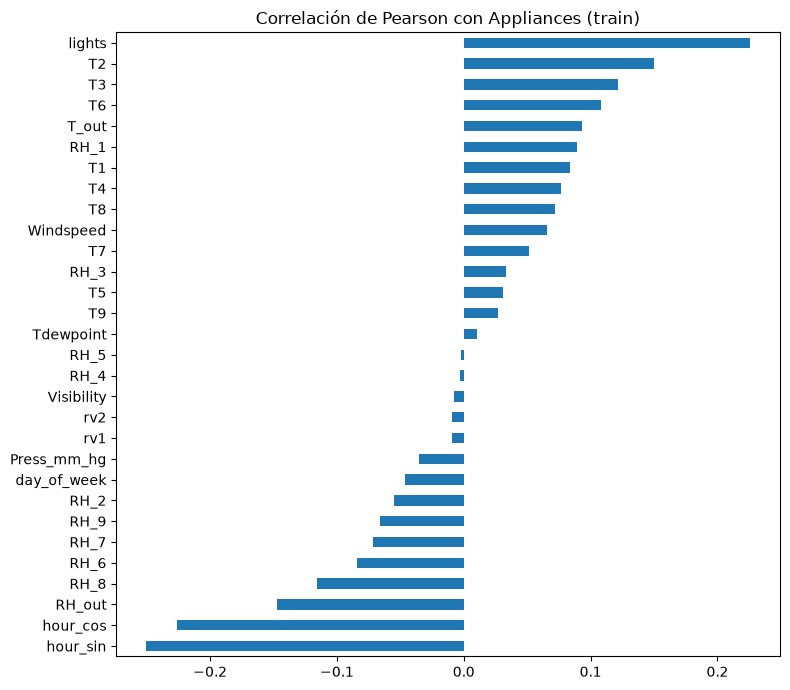

In [12]:
import matplotlib.pyplot as plt

corr_target = X_train.corrwith(y_train).sort_values(key=np.abs, ascending=False)
display(corr_target.to_frame("corr_pearson").head(15))

fig, ax = plt.subplots(figsize=(8, 7))
corr_target.sort_values().plot.barh(ax=ax)
ax.set_title("Correlación de Pearson con Appliances (train)")
plt.tight_layout(); plt.show()

Parte 6

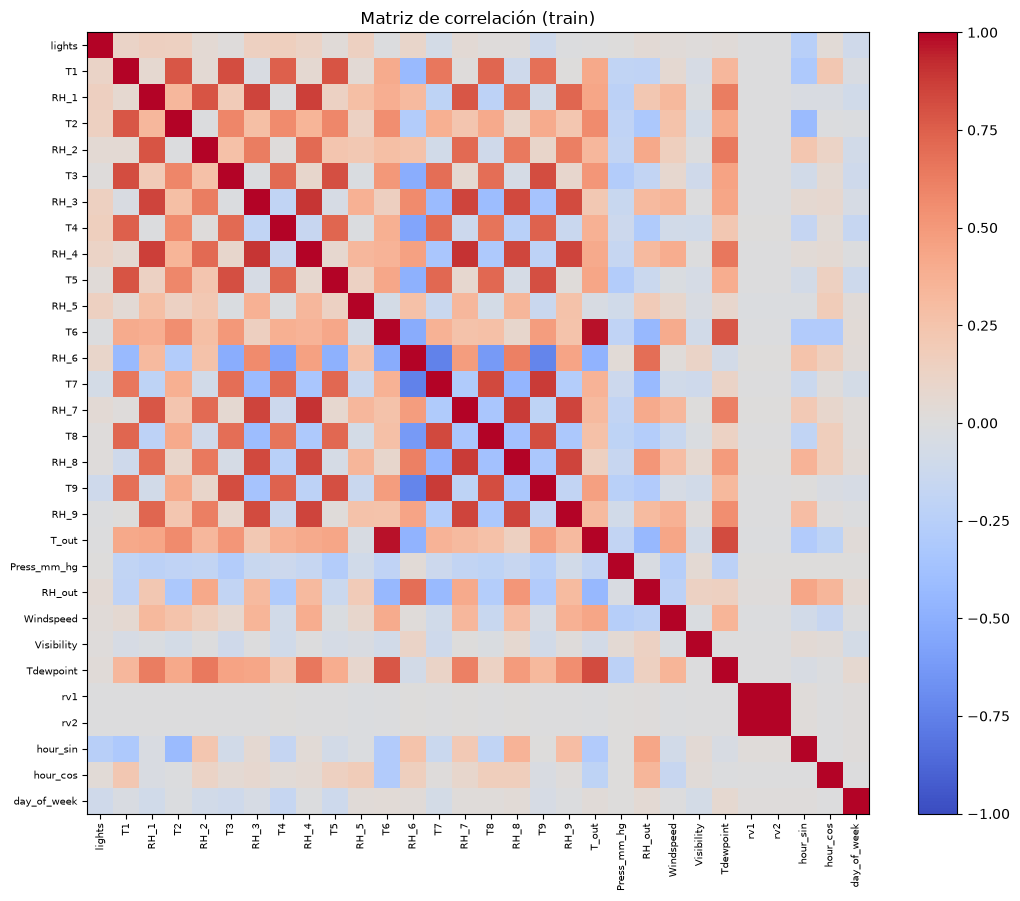

In [13]:
corr_mat = X_train.corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_mat, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_mat))); ax.set_xticklabels(corr_mat.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr_mat))); ax.set_yticklabels(corr_mat.columns, fontsize=7)
plt.colorbar(im); ax.set_title("Matriz de correlación (train)")
plt.tight_layout(); plt.show()

In [14]:
pares = (corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
         .stack().rename("corr").reset_index())
pares.columns = ["var_a", "var_b", "corr"]
pares = pares[pares["corr"].abs() > 0.9].sort_values("corr", key=np.abs, ascending=False)
print("Pares con |r| > 0.9:", len(pares))
display(pares)

Pares con |r| > 0.9: 2


,var_a,var_b,corr
776,rv1,rv2,1.000000
349,T6,T_out,0.973869


In [15]:
pares_08 = (corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
            .stack().rename("corr").reset_index())
pares_08.columns = ["var_a", "var_b", "corr"]
pares_08 = pares_08[pares_08["corr"].abs() > 0.8].sort_values("corr", key=np.abs, ascending=False)
print("Pares con |r| > 0.8:", len(pares_08))
display(pares_08)

print(corr_target[["rv1", "rv2"]])

Pares con |r| > 0.8: 22


,var_a,var_b,corr
776,rv1,rv2,1.000000
349,T6,T_out,0.973869
254,RH_4,RH_7,0.899480
188,RH_3,RH_4,0.898054
436,RH_7,RH_8,0.880703
407,T7,T9,0.880619
68,RH_1,RH_4,0.860672
498,RH_8,RH_9,0.851155
258,RH_4,RH_9,0.848194
438,RH_7,RH_9,0.847945


rv1   -0.009343
rv2   -0.009343
dtype: float64


parte 7

In [16]:
from sklearn.feature_selection import mutual_info_regression
SEED = 42

ranking = pd.DataFrame(index=X.columns)
ranking["abs_corr"] = X_train.corrwith(y_train).abs()
ranking["mutual_info"] = mutual_info_regression(X_train, y_train, random_state=SEED)

display(ranking.sort_values("mutual_info", ascending=False).round(4))

,abs_corr,mutual_info
hour_sin,0.2502,0.1687
T9,0.0270,0.1212
T3,0.1214,0.1199
T4,0.0770,0.1163
T8,0.0719,0.1152
Press_mm_hg,0.0353,0.1119
hour_cos,0.2261,0.1094
T2,0.1496,0.1082
T5,0.0312,0.1028
RH_6,0.0839,0.1005


parte 8

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV

sc_tmp = StandardScaler().fit(X_train)
lasso = LassoCV(cv=5, random_state=SEED, max_iter=5000).fit(sc_tmp.transform(X_train), y_train)

ranking["lasso_abs_coef"] = np.abs(lasso.coef_)
print("Variables con coeficiente != 0:", int((lasso.coef_ != 0).sum()))
display(ranking["lasso_abs_coef"].sort_values(ascending=False).head(15).round(3))

Variables con coeficiente != 0: 23


T3          30.439
hour_cos    25.376
RH_1        19.491
lights      17.418
hour_sin    16.436
RH_3        16.312
RH_2        16.193
T9          13.229
RH_4         9.988
T8           9.335
T2           8.076
T4           5.864
RH_7         4.919
RH_9         4.298
RH_8         4.065
Name: lasso_abs_coef, dtype: float64

In [18]:
print("Descartadas por Lasso:", list(ranking.index[ranking["lasso_abs_coef"] == 0]))
print(ranking.loc[["rv1", "rv2"], "lasso_abs_coef"])

Descartadas por Lasso: ['RH_6', 'T7', 'T_out', 'Tdewpoint', 'rv1', 'rv2', 'day_of_week']
rv1    0.0
rv2    0.0
Name: lasso_abs_coef, dtype: float64


parte 9

In [19]:
import warnings
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
warnings.filterwarnings("ignore")

def make_rna(seed=SEED):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(64, 32), activation="relu",
                             max_iter=800, shuffle=False, random_state=seed))
    ])

rna_full_tmp = make_rna().fit(X_train, y_train)
perm = permutation_importance(rna_full_tmp, X_val, y_val, n_repeats=5,
                              scoring="neg_mean_absolute_error", random_state=SEED)
ranking["perm_importance"] = perm.importances_mean

display(ranking["perm_importance"].sort_values(ascending=False).round(3))

RH_2           22.686
hour_sin       21.402
hour_cos       13.004
T2              9.639
T4              7.037
T1              5.756
T3              5.445
day_of_week     5.065
T9              4.875
RH_1            4.728
RH_7            4.169
T6              3.706
RH_5            3.422
RH_out          3.377
T8              3.368
RH_6            3.192
T7              2.492
RH_9            2.456
RH_3            1.794
rv1             1.730
rv2             1.674
RH_4            1.662
RH_8            1.630
T_out           1.426
Press_mm_hg     1.041
Tdewpoint       0.952
Windspeed       0.604
lights          0.527
T5              0.502
Visibility      0.213
Name: perm_importance, dtype: float64

parte 10

In [20]:
rangos = ranking[["abs_corr", "mutual_info", "lasso_abs_coef", "perm_importance"]].rank(ascending=False)
ranking["rango_medio"] = rangos.mean(axis=1)

ranking_ord = ranking.sort_values("rango_medio")
display(ranking_ord.round(3))

,abs_corr,mutual_info,lasso_abs_coef,perm_importance,rango_medio
hour_sin,0.250,0.169,16.436,21.402,2.25
hour_cos,0.226,0.109,25.376,13.004,3.50
T3,0.121,0.120,30.439,5.445,4.25
T2,0.150,0.108,8.076,9.639,6.75
T4,0.077,0.116,5.864,7.037,8.50
RH_1,0.089,0.080,19.491,4.728,10.25
T9,0.027,0.121,13.229,4.875,10.75
T8,0.072,0.115,9.335,3.368,11.00
T1,0.084,0.088,1.819,5.756,11.75
RH_2,0.055,0.051,16.193,22.686,12.25


parte 11

In [21]:
from sklearn.feature_selection import mutual_info_regression

K = 12
bloques = np.array_split(np.arange(len(X_train)), 4)
freq = pd.Series(0, index=X.columns, dtype=int)

for idx in bloques:
    mi = pd.Series(
        mutual_info_regression(X_train.iloc[idx], y_train.iloc[idx], random_state=SEED),
        index=X.columns
    )
    freq[mi.nlargest(K).index] += 1

estab = freq.sort_values(ascending=False).to_frame("veces_en_top12_de_4")
print(estab.to_string())

             veces_en_top12_de_4
Press_mm_hg                    4
T2                             3
T6                             3
hour_sin                       3
T_out                          3
RH_6                           3
hour_cos                       3
T5                             2
RH_4                           2
RH_9                           2
RH_5                           2
T4                             2
T3                             2
RH_2                           2
RH_7                           2
RH_8                           2
RH_out                         1
RH_1                           1
lights                         1
T7                             1
T1                             1
T8                             1
Tdewpoint                      1
T9                             1
RH_3                           0
Windspeed                      0
rv1                            0
Visibility                     0
rv2                            0
day_of_wee

In [22]:
K = 12

def poda_redundancia(orden, corr_mat, umbral=0.9, k=12):
    elegidas = []
    for v in orden:
        if all(abs(corr_mat.loc[v, e]) <= umbral for e in elegidas):
            elegidas.append(v)
        if len(elegidas) == k:
            break
    return elegidas

subset_A = poda_redundancia(ranking["abs_corr"].sort_values(ascending=False).index, corr_mat, 0.9, K)
subset_B = list(ranking["mutual_info"].nlargest(K).index)
subset_C = list(ranking["perm_importance"].nlargest(K).index)
subset_D = list(ranking.index[ranking["lasso_abs_coef"] > 0])

conteo = pd.Series(0, index=X.columns)
for s in (subset_A, subset_B, subset_C, subset_D):
    conteo[s] += 1
subset_E = [v for v in conteo.index[conteo >= 3] if v not in ("rv1", "rv2")]

candidatos = {
    "Todas": list(X.columns),
    "A_corr_poda": subset_A,
    "B_info_mutua": subset_B,
    "C_permutacion": subset_C,
    "D_lasso": subset_D,
    "E_consenso": subset_E,
}
for nombre, vs in candidatos.items():
    print(f"{nombre:15s} ({len(vs):2d} vars): {vs}")

Todas           (30 vars): ['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2', 'hour_sin', 'hour_cos', 'day_of_week']
A_corr_poda     (12 vars): ['hour_sin', 'hour_cos', 'lights', 'T2', 'RH_out', 'T3', 'RH_8', 'T6', 'RH_1', 'T1', 'RH_6', 'T4']
B_info_mutua    (12 vars): ['hour_sin', 'T9', 'T3', 'T4', 'T8', 'Press_mm_hg', 'hour_cos', 'T2', 'T5', 'RH_6', 'T7', 'RH_8']
C_permutacion   (12 vars): ['RH_2', 'hour_sin', 'hour_cos', 'T2', 'T4', 'T1', 'T3', 'day_of_week', 'T9', 'RH_1', 'RH_7', 'T6']
D_lasso         (23 vars): ['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'hour_sin', 'hour_cos']
E_consenso      (10 vars): ['T1', 'RH_1', 'T2', 'T3', 'T4', 'T6', 'RH_8', 'T9', 'hour_sin', 'hour_cos']


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluar(modelo, Xa, ya):
    p = modelo.predict(Xa)
    return {"MAE": mean_absolute_error(ya, p),
            "RMSE": np.sqrt(mean_squared_error(ya, p)),
            "R2": r2_score(ya, p)}

filas = []
for nombre, vs in candidatos.items():
    m = make_rna(SEED).fit(X_train[vs], y_train)
    filas.append({"conjunto": nombre, "n_vars": len(vs), **evaluar(m, X_val[vs], y_val)})

res_val = pd.DataFrame(filas).set_index("conjunto")
print(res_val.round(3).to_string())

               n_vars     MAE     RMSE     R2
conjunto                                     
Todas              30  60.759  104.607 -0.286
A_corr_poda        12  60.625  101.327 -0.207
B_info_mutua       12  62.996   98.739 -0.146
C_permutacion      12  61.799   98.868 -0.149
D_lasso            23  67.770  115.178 -0.559
E_consenso         10  61.018   98.652 -0.144


In [24]:
from sklearn.dummy import DummyRegressor

# Línea base: predecir siempre un valor fijo (calculado en train)
for estrategia in ("mean", "median"):
    base = DummyRegressor(strategy=estrategia).fit(X_train, y_train)
    r = evaluar(base, X_val, y_val)
    print(f"Base ({estrategia}):", {k: round(v, 3) for k, v in r.items()})

# 5 semillas por conjunto
filas = []
for nombre, vs in candidatos.items():
    for s in range(5):
        m = make_rna(s).fit(X_train[vs], y_train)
        filas.append({"conjunto": nombre, "seed": s, **evaluar(m, X_val[vs], y_val)})

multi = pd.DataFrame(filas)
resumen = multi.groupby("conjunto")[["MAE", "RMSE", "R2"]].agg(["mean", "std"])
print(resumen.round(3).to_string())

Base (mean): {'MAE': 53.968, 'RMSE': np.float64(92.394), 'R2': -0.003}
Base (median): {'MAE': 42.605, 'RMSE': np.float64(98.108), 'R2': -0.131}
                  MAE            RMSE            R2       
                 mean    std     mean    std   mean    std
conjunto                                                  
A_corr_poda    60.652  3.148  101.562  3.382 -0.213  0.082
B_info_mutua   66.431  5.196  104.590  4.613 -0.288  0.113
C_permutacion  67.764  6.057  108.838  4.465 -0.394  0.116
D_lasso        69.994  4.779  110.977  4.775 -0.450  0.125
E_consenso     59.594  2.045  101.994  2.164 -0.223  0.051
Todas          64.812  2.514  109.113  4.640 -0.401  0.119


In [25]:
from sklearn.dummy import DummyRegressor

selected_features = candidatos["E_consenso"]
print(selected_features)

X_trval = pd.concat([X_train, X_val])
y_trval = pd.concat([y_train, y_val])

final = {}
for nombre, vs in {"Todas": list(X.columns), "E_consenso": selected_features}.items():
    m = make_rna(SEED).fit(X_trval[vs], y_trval)
    final[nombre] = {"n_vars": len(vs), **evaluar(m, X_test[vs], y_test)}

for estrategia in ("mean", "median"):
    base = DummyRegressor(strategy=estrategia).fit(X_trval, y_trval)
    final[f"Base_{estrategia}"] = {"n_vars": 0, **evaluar(base, X_test, y_test)}

print(pd.DataFrame(final).T.round(3).to_string())

['T1', 'RH_1', 'T2', 'T3', 'T4', 'T6', 'RH_8', 'T9', 'hour_sin', 'hour_cos']
             n_vars      MAE     RMSE     R2
Todas          30.0  149.949  195.664 -3.636
E_consenso     10.0  110.216  144.944 -1.544
Base_mean       0.0   52.398   90.878 -0.000
Base_median     0.0   43.256   98.089 -0.165


In [26]:
vs = selected_features

# Períodos de cada partición
print("train:", df.loc[0, "date"], "->", df.loc[fin_train - 1, "date"])
print("val:  ", df.loc[fin_train, "date"], "->", df.loc[fin_val - 1, "date"])
print("test: ", df.loc[fin_val, "date"], "->", df.loc[n - 1, "date"])

# ¿Cuánto de la prueba cae fuera del rango visto en entrenamiento+validación?
fuera = ((X_test[vs] < X_trval[vs].min()) | (X_test[vs] > X_trval[vs].max())).mean() * 100
rango = pd.DataFrame({
    "tr_min": X_trval[vs].min(), "tr_max": X_trval[vs].max(),
    "te_min": X_test[vs].min(), "te_max": X_test[vs].max(),
    "%_test_fuera": fuera,
})
print(rango.round(2).to_string())

train: 2016-01-11 17:00:00 -> 2016-04-16 15:10:00
val:   2016-04-16 15:20:00 -> 2016-05-07 04:30:00
test:  2016-05-07 04:40:00 -> 2016-05-27 18:00:00
          tr_min  tr_max  te_min  te_max  %_test_fuera
T1         16.79   24.89   22.70   26.26         21.58
RH_1       27.02   63.36   30.79   54.67          0.00
T2         16.10   27.10   20.20   29.86          5.57
T3         17.20   27.60   23.00   29.24          3.85
T4         15.10   24.29   22.50   26.20         39.11
T6         -6.06   24.47    1.90   28.29          8.85
RH_8       29.60   58.78   31.33   55.00          0.00
T9         14.89   23.84   21.52   24.50         18.17
hour_sin   -1.00    1.00   -1.00    1.00          0.00
hour_cos   -1.00    1.00   -1.00    1.00          0.00


## 10. Discusión y conclusión

### 10.1 Resumen de resultados

**Validación** (misma arquitectura MLP 64-32, semilla oficial 42; además media ± desvío con 5 semillas):

| Conjunto | Vars | MAE (5 semillas) | RMSE (5 semillas) | R² (5 semillas) |
|---|---|---|---|---|
| E consenso | 10 | 59,6 ± 2,0 | 102,0 ± 2,2 | -0,223 |
| A correlación + poda | 12 | 60,7 ± 3,1 | 101,6 ± 3,4 | -0,213 |
| Todas | 30 | 64,8 ± 2,5 | 109,1 ± 4,6 | -0,401 |
| B información mutua | 12 | 66,4 ± 5,2 | 104,6 ± 4,6 | -0,288 |
| C permutación | 12 | 67,8 ± 6,1 | 108,8 ± 4,5 | -0,394 |
| D Lasso | 23 | 70,0 ± 4,8 | 111,0 ± 4,8 | -0,450 |

Líneas base en validación (predecir siempre un valor fijo calculado en entrenamiento): media MAE 53,97 / RMSE 92,39 / R² -0,003; mediana MAE 42,61 / RMSE 98,11 / R² -0,131.

**Prueba** (una sola evaluación, configuración congelada, reentrenando con entrenamiento + validación, semilla 42):

| Modelo | Vars | MAE | RMSE | R² |
|---|---|---|---|---|
| RNA con todas las variables | 30 | 149,9 | 195,7 | -3,636 |
| RNA con subconjunto E | 10 | 110,2 | 144,9 | -1,544 |
| Línea base (media) | 0 | 52,4 | 90,9 | -0,000 |
| Línea base (mediana) | 0 | 43,3 | 98,1 | -0,165 |

### 10.2 Selección final y justificación

Se elige el subconjunto **E (consenso)**: `T1, RH_1, T2, T3, T4, T6, RH_8, T9, hour_sin, hour_cos`.

- Tiene el menor MAE medio en validación (59,6), el menor desvío entre semillas (2,0) y solo 10 variables.
- Su diferencia con A (corrección + poda) no es distinguible del ruido entre semillas; se prefirió E por el menor MAE, la menor variabilidad y la menor cantidad de variables.
- Le gana a "Todas" en validación por unos 5 Wh de MAE y 7 Wh de RMSE, una diferencia mayor que la variación entre semillas, y esa dirección se repite en prueba (MAE 110,2 contra 149,9).
- Los subconjuntos B, C y D no se distinguieron de "Todas", o fueron peores. Elegir variables solo por un ranking de información mutua, de permutación o de Lasso no mejoró a la red.
- E se arma con las variables que aparecen en al menos 3 de los 4 subconjuntos A–D (excluyendo `rv1` y `rv2`). El umbral de 3 votos, igual que K = 12, es una decisión de diseño y no un resultado estadístico.

### 10.3 Relevancia y estabilidad

- Las variables más consistentes entre técnicas fueron `hour_sin` y `hour_cos` (rangos 2,25 y 3,50 en el ranking agregado), seguidas de temperaturas interiores (`T3`, `T2`, `T4`). La hora del día es el factor dominante, y solo tiene sentido conjuntamente (seno y coseno describen un punto del círculo diario).
- En la estabilidad por 4 bloques cronológicos del entrenamiento (información mutua, top 12), solo `Press_mm_hg` apareció en los 4 bloques; luego `hour_sin`, `hour_cos`, `T2`, `T6`, `T_out` y `RH_6` en 3. Pero `Press_mm_hg` recibió en permutación una importancia (1,04) por debajo del nivel de ruido, por lo que la estabilidad no implica utilidad: información mutua y permutación discrepan sobre esa variable. `T9` tuvo información mutua alta en conjunto pero apareció en un solo bloque, lo que indica inestabilidad.
- Algunas variables solo las detecta una técnica: `RH_2` fue la primera por permutación pero no por correlación ni información mutua, y `day_of_week` tuvo importancia por permutación y fue descartada por Lasso (lineal). Un promedio de rangos entierra estas variables, por lo que se lo usó como guía y no como veredicto.
- Los resultados de importancia por permutación provienen de una sola red y de pocas repeticiones, por lo que sus valores son estimaciones con incertidumbre.

### 10.4 Redundancia

- Pares con |r| > 0.9: `rv1`-`rv2` (r = 1,000) y `T6`-`T_out` (r = 0,974). Con |r| > 0.8 se observan 22 pares organizados en bloques: humedades interiores (`RH_1`, `RH_3`, `RH_4`, `RH_7`, `RH_8`, `RH_9`), temperaturas interiores (`T1`, `T3`, `T5`, `T7`, `T8`, `T9`) y el grupo exterior (`T_out` con `Tdewpoint`).
- El umbral de 0,9 es arbitrario: `RH_4`-`RH_7` (0,8995) y `RH_3`-`RH_4` (0,898) quedaron justo por debajo.
- La poda del subconjunto A descartó `T_out` y conservó `T6`, que era la más informativa del par.
- El subconjunto E, armado por votos, no considera redundancia: incluye `T1`, `T3` y `T9`, que pertenecen al bloque correlacionado (r de 0,81 a 0,82). Es una limitación del criterio de consenso.

### 10.5 Papel de `rv1` y `rv2`

- Son la misma columna duplicada (valores idénticos), sin relación con el consumo (correlación -0,009; información mutua 0). Lasso las puso en cero y quedaron en el último lugar del ranking agregado.
- Se usaron como línea de base de ruido. La red entrenada con las 30 variables les asignó, sin embargo, importancia por permutación positiva (1,73 y 1,67), lo que indica que memorizó ruido. Las variables con importancia por debajo de ese nivel no se distinguen de ruido en este modelo: `RH_4`, `RH_8`, `T_out`, `Press_mm_hg`, `Tdewpoint`, `Windspeed`, `lights`, `T5` y `Visibility`.
- La diferencia entre la importancia de `rv1` y `rv2` (idénticas) da una idea del margen de error de la propia medición.

### 10.6 Posibles fugas de información (leakage)

- Los rankings de correlación, información mutua, Lasso y estabilidad se calcularon solo con entrenamiento.
- La importancia por permutación se evaluó sobre validación, no sobre prueba. El `StandardScaler` está dentro del `Pipeline`, por lo que se ajusta solo con los datos con los que se entrena cada modelo.
- La partición es cronológica (70/15/15), sin mezclar filas, para evitar que el modelo "espíe" registros contiguos del futuro.
- La prueba se evaluó una sola vez con la configuración congelada. El análisis posterior de rangos sobre la prueba fue solo descriptivo y no modificó la selección.
- Los conjuntos candidatos se compararon y se eligió entre ellos usando validación, lo que introduce un pequeño sesgo de selección en las métricas de validación.
- No se usaron rezagos de `Appliances`. La variable `lights` (consumo eléctrico de la misma casa) quedó fuera del subconjunto E; si se la usara, habría que confirmar que estaría disponible al momento de predecir.

### 10.7 Limitaciones

- **Ninguna red supera a la línea base.** En validación la mejor red (MAE 59,6) queda por encima del MAE de predecir la mediana (42,6), y en prueba la diferencia es mayor (110,2 contra 43,3). Todos los R² son negativos. Con esta arquitectura y estas variables, la RNA no mejora a un modelo trivial; la selección reduce el error respecto de usar todas las variables, pero no lo lleva por debajo de la línea base.
- **Cambio de período.** El entrenamiento cubre del 11/01 al 16/04/2016, la validación hasta el 07/05 y la prueba del 07/05 al 27/05. En la prueba varias temperaturas del subconjunto E salen del rango visto en entrenamiento y validación (`T4` el 39 % de las filas, `T1` el 22 %, `T9` el 18 %, `T6` el 9 %, `T2` el 6 %, `T3` el 4 %), mientras que las humedades elegidas y la hora no. Un MLP con activación ReLU puede extrapolar de forma errática fuera de rango, lo que es una explicación plausible del deterioro entre validación y prueba, aunque este análisis no demuestra que sea la única causa.
- **Una sola partición temporal y una sola semilla en la prueba.** En validación la variabilidad entre semillas es de 2 a 6 Wh de MAE, por lo que las diferencias pequeñas entre conjuntos no son concluyentes.
- **La arquitectura, fijada por la consigna, no tiene regularización ni parada temprana**, lo que favorece el sobreajuste. El objetivo es muy asimétrico (muchos valores bajos y pocos picos), y la pérdida cuadrática de la red lo penaliza.
- **Mejoras posibles (no aplicadas, para no usar la prueba en las decisiones):** conjuntos con menos dependencia de temperaturas interiores, validación cruzada temporal con varias ventanas, regularización o parada temprana, y una transformación del objetivo.

### 10.8 Conclusión

La selección de variables mejora a la RNA respecto de usar las 30 variables: el subconjunto E, de 10 variables, redujo el MAE de validación en unos 5 Wh y el de prueba de 149,9 a 110,2, con menor variabilidad entre semillas. Las variables temporales (`hour_sin`, `hour_cos`) y las temperaturas interiores concentran la relevancia, y `rv1` y `rv2` sirvieron como control de ruido. Sin embargo, ninguna red superó a un modelo que predice siempre la mediana o la media, y el desempeño en prueba se deterioró mucho por un cambio de condiciones entre períodos. Estos resultados indican que, con esta arquitectura, la selección ayuda pero no alcanza, y que la validez de la conclusión se limita a una partición temporal y una semilla.